In [8]:
import importlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

In [9]:
import measurements.SphereGenerator as sg
import measurements.Image_2_points as e2p

# sg = importlib.reload(sg)
# e2p = importlib.reload(e2p)

Saved 12 images to: Body_Images
Manifest: Body_Images/manifest.jsonl

Edge pixel counts (first 5):
  body_00000.png: 2119
  body_00001.png: 1374
  body_00002.png: 1789
  body_00003.png: 2214
  body_00004.png: 1520


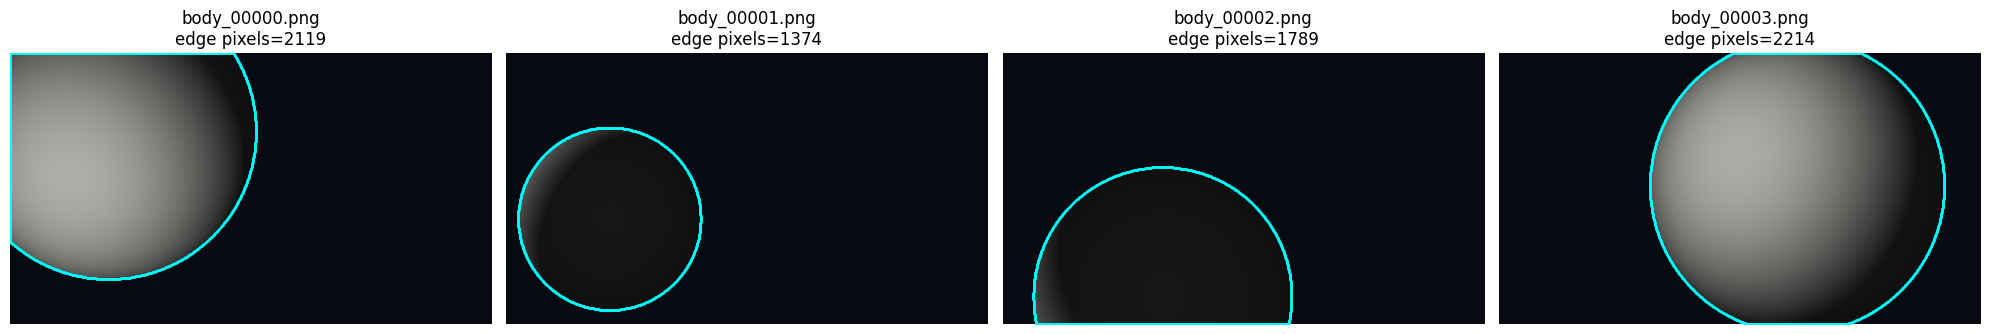


First manifest record keys:
['angular_diameter_deg', 'body', 'camera', 'center_px', 'image_file', 'image_shape', 'radius_px', 'sample_angles_deg', 'sample_forward_offset_world', 'sample_position_world']


In [10]:


# --- Scene setup ---
camera = sg.CameraSettings(
    width=1280,
    height=720,
    horizontal_fov_deg=60.0,
    position_world=np.array([0.0, 0.0, 4_000.0]),
    forward_world=np.array([0.0, 0.0, -1.0]),
    up_world=np.array([0.0, 1.0, 0.0]),
)

body = sg.CelestialBody(
    center_world=np.array([0.0, 0.0, 0.0]),
    radius=1_737_400.0,
    albedo_rgb=(185, 185, 180),
)

# --- 1) Generate + save dataset with manifest metadata ---
results, saved_paths, manifest_path = sg.generate_and_save_randomized_dataset(
    body=body,
    template_camera=camera,
    sample_count=12,
    min_distance=3_000_000.0,
    max_distance=9_000_000.0,
    output_dir="Body_Images",
    file_prefix="body",
    visibility_mode="limb",
    seed=22,
    background_rgb=(8, 10, 18),
    light_direction_world=[1.0, 0.2, 0.6],
)

print(f"Saved {len(saved_paths)} images to: {Path(saved_paths[0]).parent if saved_paths else 'Body_Images'}")
print(f"Manifest: {manifest_path}")

# --- 2) Edge detection on saved images ---
edge_counts = []
for image_path in saved_paths:
    edge_result = e2p.find_body_edge_pixels_from_path(image_path, color_tolerance=8.0)
    edge_counts.append((Path(image_path).name, len(edge_result.edge_coordinates_xy)))

print("\nEdge pixel counts (first 5):")
for name, count in edge_counts[:5]:
    print(f"  {name}: {count}")

# --- 3) Visual overlay preview for first 4 images ---
preview_n = min(4, len(saved_paths))
fig, axes = plt.subplots(1, preview_n, figsize=(5 * preview_n, 5))
if preview_n == 1:
    axes = [axes]

for i in range(preview_n):
    img = e2p.load_image_rgb(saved_paths[i])
    edge_result = e2p.find_body_edge_pixels(img, color_tolerance=8.0)

    ax = axes[i]
    ax.imshow(img)
    coords = edge_result.edge_coordinates_xy
    if len(coords) > 0:
        ax.scatter(coords[:, 0], coords[:, 1], s=0.5, c="cyan", alpha=0.8)
    ax.set_title(f"{Path(saved_paths[i]).name}\nedge pixels={len(coords)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# --- 4) Example: read one manifest record ---
with open(manifest_path, "r", encoding="utf-8") as f:
    first_record = json.loads(f.readline())

print("\nFirst manifest record keys:")
print(sorted(first_record.keys()))

Image: Body_Images/moon.jpg
Detected edge pixels (largest component only): 2623


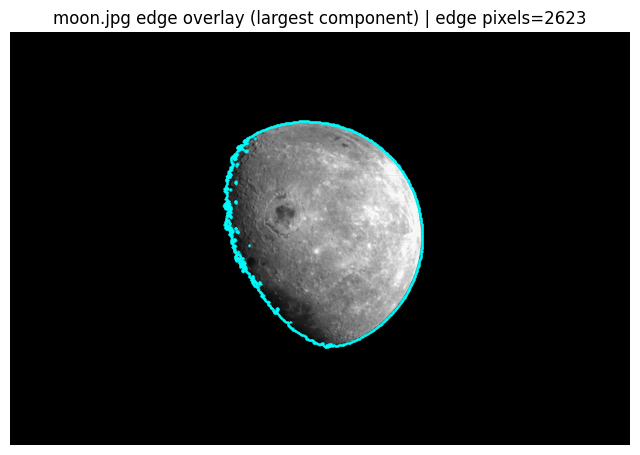

In [11]:


# e2p = importlib.reload(e2p)

moon_path = Path("Body_Images") / "moon.jpg"
img = e2p.load_image_rgb(moon_path)

# You can tune color_tolerance if needed (try 6-20).
moon_edges = e2p.find_body_edge_pixels(
    image_rgb=img,
    background_rgb=None,
    color_tolerance=12.0,
    keep_largest_component_only=True,
)

coords = moon_edges.edge_coordinates_xy
print(f"Image: {moon_path}")
print(f"Detected edge pixels (largest component only): {len(coords)}")

plt.figure(figsize=(8, 8))
plt.imshow(img)
if len(coords) > 0:
    plt.scatter(coords[:, 0], coords[:, 1], s=0.2, c="cyan", alpha=0.8)
plt.title(f"moon.jpg edge overlay (largest component) | edge pixels={len(coords)}")
plt.axis("off")
plt.show()

In [12]:
# --- Noise tuning quick switch ---
# Choose one: "clean", "light", "medium", "heavy"
profile = "medium"

noise_profiles = {
    "clean": sg.NoiseSettings(shot_noise_strength=0.0, read_noise_std=0.0, dark_bias=0.0, vignette_strength=0.0, seed=321),
    "light": sg.NoiseSettings(shot_noise_strength=0.025, read_noise_std=0.006, dark_bias=0.0, vignette_strength=0.05, seed=321),
    "medium": sg.NoiseSettings(shot_noise_strength=0.05, read_noise_std=0.012, dark_bias=0.0, vignette_strength=0.10, seed=321),
    "heavy": sg.NoiseSettings(shot_noise_strength=0.09, read_noise_std=0.02, dark_bias=0.005, vignette_strength=0.18, seed=321),
}

if profile not in noise_profiles:
    raise ValueError(f"Unknown profile '{profile}'. Use one of: {list(noise_profiles.keys())}")

noise = noise_profiles[profile]

clean_result = sg.render_celestial_body(
    camera=camera,
    body=body,
    background_rgb=(8, 10, 18),
    light_direction_world=[1.0, 0.2, 0.6],
    ambient=0.10,
    diffuse_strength=0.90,
    limb_darkening_strength=0.40,
    limb_darkening_power=1.2,
    noise_settings=None,
)

noisy_result = sg.render_celestial_body(
    camera=camera,
    body=body,
    background_rgb=(8, 10, 18),
    light_direction_world=[1.0, 0.2, 0.6],
    ambient=0.10,
    diffuse_strength=0.90,
    limb_darkening_strength=0.40,
    limb_darkening_power=1.2,
    noise_settings=noise,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axis_top: Axes = axes[0]
axis_bot: Axes = axes[1]
axis_top.imshow(clean_result.image)
axis_top.set_title("clean")
axis_top.axis("off")

axis_bot.imshow(noisy_result.image)
axis_bot.set_title(f"noisy ({profile})")
axis_bot.axis("off")

plt.tight_layout()
plt.show()

print(f"Active noise profile: {profile}")
print(noise)

ValueError: Camera must be outside the celestial body (distance > radius).

In [ ]:

# e2p = importlib.reload(e2p)

# If this variable is missing, run Cell 4 first to generate noisy images.
if "noisy_paths" not in globals() or len(noisy_paths) == 0:
    raise RuntimeError("noisy_paths not found. Run Cell 4 first.")

noisy_edge_counts = []
noisy_edge_results = []
edge_points_by_image = {}
annotated_edge_data = {}

# --- Load manifest records (prefer noisy_manifest when available) ---
manifest_records_by_file = {}
manifest_candidates = []
if "noisy_manifest" in globals() and noisy_manifest is not None:
    manifest_candidates.append(Path(noisy_manifest))
if "manifest_path" in globals() and manifest_path is not None:
    manifest_candidates.append(Path(manifest_path))

for mp in manifest_candidates:
    if not mp.exists():
        continue
    with open(mp, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec: dict = json.loads(line)
            except json.JSONDecodeError:
                continue
            image_file = rec.get("image_file")
            if image_file:
                manifest_records_by_file[Path(image_file).name] = rec
    if manifest_records_by_file:
        break

# --- Build per-image edge list + metadata annotations ---
for p in noisy_paths:
    edge_res = e2p.find_body_edge_pixels_from_path(
        p,
        color_tolerance=7.0,
        keep_largest_component_only=True,
        fill_internal_holes=True,
        remove_speckles=True,
        min_speckle_neighbors=3,
        speckle_iterations=1,
    )
    noisy_edge_results.append(edge_res)

    image_name = Path(p).name
    edge_points = [(int(x), int(y)) for x, y in edge_res.edge_coordinates_xy]
    edge_points_by_image[image_name] = edge_points
    noisy_edge_counts.append((image_name, len(edge_points)))

    rec = manifest_records_by_file.get(image_name, {})

    # Distance (meters)
    distance_m = None
    if rec:
        sample_pos = rec.get("sample_position_world")
        body_center = rec.get("body", {}).get("center_world")
        if sample_pos is not None and body_center is not None:
            distance_m = float(np.linalg.norm(np.asarray(sample_pos, dtype=np.float64) - np.asarray(body_center, dtype=np.float64)))
        else:
            cam_pos = rec.get("camera", {}).get("position_world")
            if cam_pos is not None and body_center is not None:
                distance_m = float(np.linalg.norm(np.asarray(cam_pos, dtype=np.float64) - np.asarray(body_center, dtype=np.float64)))

    if distance_m is None and "camera" in globals() and "body" in globals():
        distance_m = float(np.linalg.norm(
            np.asarray(camera.position_world, dtype=np.float64) - np.asarray(body.center_world, dtype=np.float64)
        ))

    # Camera angle
    yaw_deg = None
    pitch_deg = None
    if rec and rec.get("sample_angles_deg") is not None and len(rec["sample_angles_deg"]) >= 2:
        yaw_deg = float(rec["sample_angles_deg"][0])
        pitch_deg = float(rec["sample_angles_deg"][1])

    offset_mag_deg = None
    if yaw_deg is not None and pitch_deg is not None:
        offset_mag_deg = float(np.sqrt(yaw_deg**2 + pitch_deg**2))

    # Camera specs
    if rec and rec.get("camera") is not None:
        cam = rec["camera"]
        camera_specs = {
            "width": int(cam.get("width")),
            "height": int(cam.get("height")),
            "horizontal_fov_deg": float(cam.get("horizontal_fov_deg")),
            "position_world": cam.get("position_world"),
            "forward_world": cam.get("forward_world"),
            "up_world": cam.get("up_world"),
        }
    elif "camera" in globals():
        camera_specs = {
            "width": int(camera.width),
            "height": int(camera.height),
            "horizontal_fov_deg": float(camera.horizontal_fov_deg),
            "position_world": np.asarray(camera.position_world, dtype=np.float64).tolist(),
            "forward_world": np.asarray(camera.forward_world, dtype=np.float64).tolist(),
            "up_world": np.asarray(camera.up_world, dtype=np.float64).tolist(),
        }
    else:
        camera_specs = None

    annotated_edge_data[image_name] = {
        "edge_points_xy": edge_points,
        "edge_point_count": len(edge_points),
        "distance_m": distance_m,
        "camera_angle_deg": {
            "yaw": yaw_deg,
            "pitch": pitch_deg,
            "offset_magnitude": offset_mag_deg,
        },
        "camera_specs": camera_specs,
    }

print("Noisy image edge counts (cleaned mask):")
for name, count in noisy_edge_counts:
    print(f"  {name}: {count}")

print("\nAnnotated edge data (first 10 points per image):")
for name, item in annotated_edge_data.items():
    angle = item["camera_angle_deg"]
    print(f"\n{name}:")
    print(f"  distance_m={item['distance_m']}")
    print(f"  camera_angle_deg(yaw,pitch,mag)=({angle['yaw']}, {angle['pitch']}, {angle['offset_magnitude']})")
    print(f"  edge_points(first 10)={item['edge_points_xy'][:10]}")

preview_n = min(6, len(noisy_paths))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes:  = axes.ravel()

for i in range(preview_n):
    img_i = e2p.load_image_rgb(noisy_paths[i])
    coords_i = noisy_edge_results[i].edge_coordinates_xy

    axes[i].imshow(img_i)
    if len(coords_i) > 0:
        axes[i].scatter(coords_i[:, 0], coords_i[:, 1], s=0.2, c="cyan", alpha=0.8)
    axes[i].set_title(f"{Path(noisy_paths[i]).name}\nedge={len(coords_i)}")
    axes[i].axis("off")

for j in range(preview_n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Access full outputs later with:
# - edge_points_by_image
# - annotated_edge_data

In [ ]:
import csv

if "annotated_edge_data" not in globals() or not annotated_edge_data:
    raise RuntimeError("annotated_edge_data is missing or empty. Run Cell 5 first.")

output_dir = Path("Body_Images")
output_dir.mkdir(parents=True, exist_ok=True)
output_csv = output_dir / "edge_points_per_image.csv"

fieldnames = [
    "image_file",
    "edge_points_xy",
    "point_count",
    "shape",
    "distance_m",
    "camera_yaw_deg",
    "camera_pitch_deg",
    "camera_offset_magnitude_deg",
    "camera_width",
    "camera_height",
    "camera_horizontal_fov_deg",
    "camera_position_world",
    "camera_forward_world",
    "camera_up_world",
]

with open(output_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for image_name, item in annotated_edge_data.items():
        points = item.get("edge_points_xy", [])
        points_xy = [[int(x), int(y)] for x, y in points]

        angle = item.get("camera_angle_deg", {}) or {}
        specs = item.get("camera_specs", {}) or {}

        writer.writerow({
            "image_file": image_name,
            "edge_points_xy": json.dumps(points_xy),
            "point_count": len(points_xy),
            "shape": json.dumps([len(points_xy), 2]),
            "distance_m": item.get("distance_m"),
            "camera_yaw_deg": angle.get("yaw"),
            "camera_pitch_deg": angle.get("pitch"),
            "camera_offset_magnitude_deg": angle.get("offset_magnitude"),
            "camera_width": specs.get("width"),
            "camera_height": specs.get("height"),
            "camera_horizontal_fov_deg": specs.get("horizontal_fov_deg"),
            "camera_position_world": json.dumps(specs.get("position_world")),
            "camera_forward_world": json.dumps(specs.get("forward_world")),
            "camera_up_world": json.dumps(specs.get("up_world")),
        })

print(f"Saved per-image edge-point arrays to: {output_csv.resolve()}")
print(f"Images exported: {len(annotated_edge_data)}")
print("\nExtraction example for one image:")
print("  import pandas as pd, json, numpy as np")
print("  df = pd.read_csv('Body_Images/edge_points_per_image.csv')")
print("  row = df[df['image_file'] == 'body_noisy_00000.png'].iloc[0]")
print("  edge_points = np.array(json.loads(row['edge_points_xy']), dtype=np.int32)")
print("  distance_m = float(row['distance_m'])")
print("  cam_pos = json.loads(row['camera_position_world'])")
print("  # edge_points shape -> (N, 2)")